In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [19]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nData types:\n",df.dtypes)
print("\nMissing values:\n",df.isnull().sum())
print("Total missing values:", df.isnull().sum().sum())

Number of rows: 299
Number of columns: 13

Data types:
 age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing values:
 age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64
Total missing values: 0


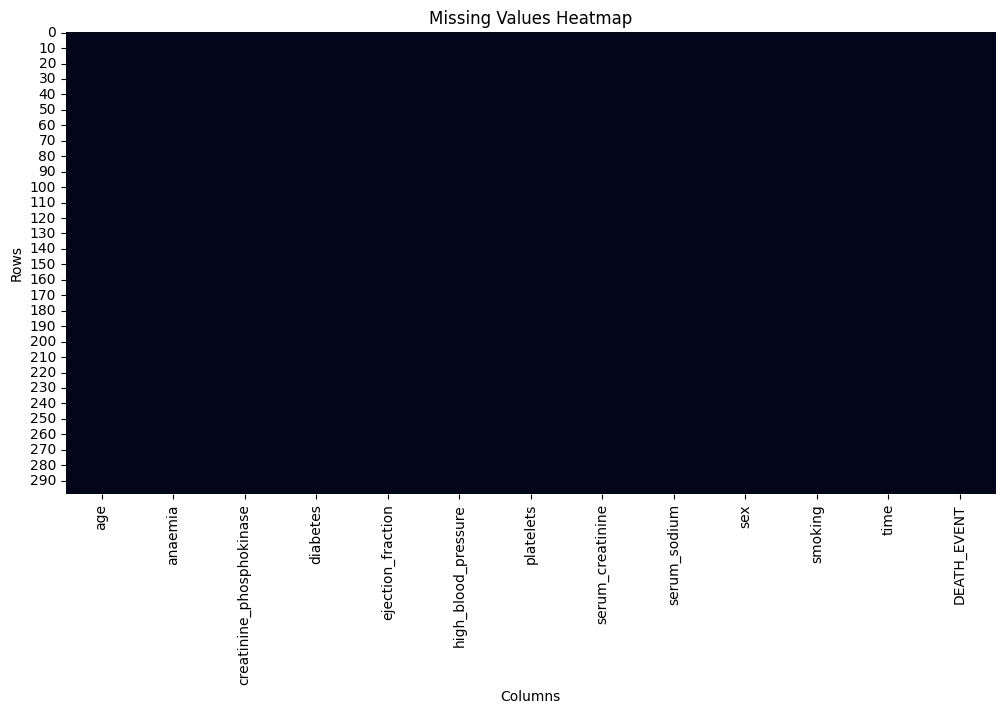

In [17]:
import seaborn as sns
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()
# no missing values in any column

In [21]:
numerical_columns = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

categorical_columns = [
    'anaemia',
    'diabetes',
    'high_blood_pressure',
    'sex',
    'smoking'
]

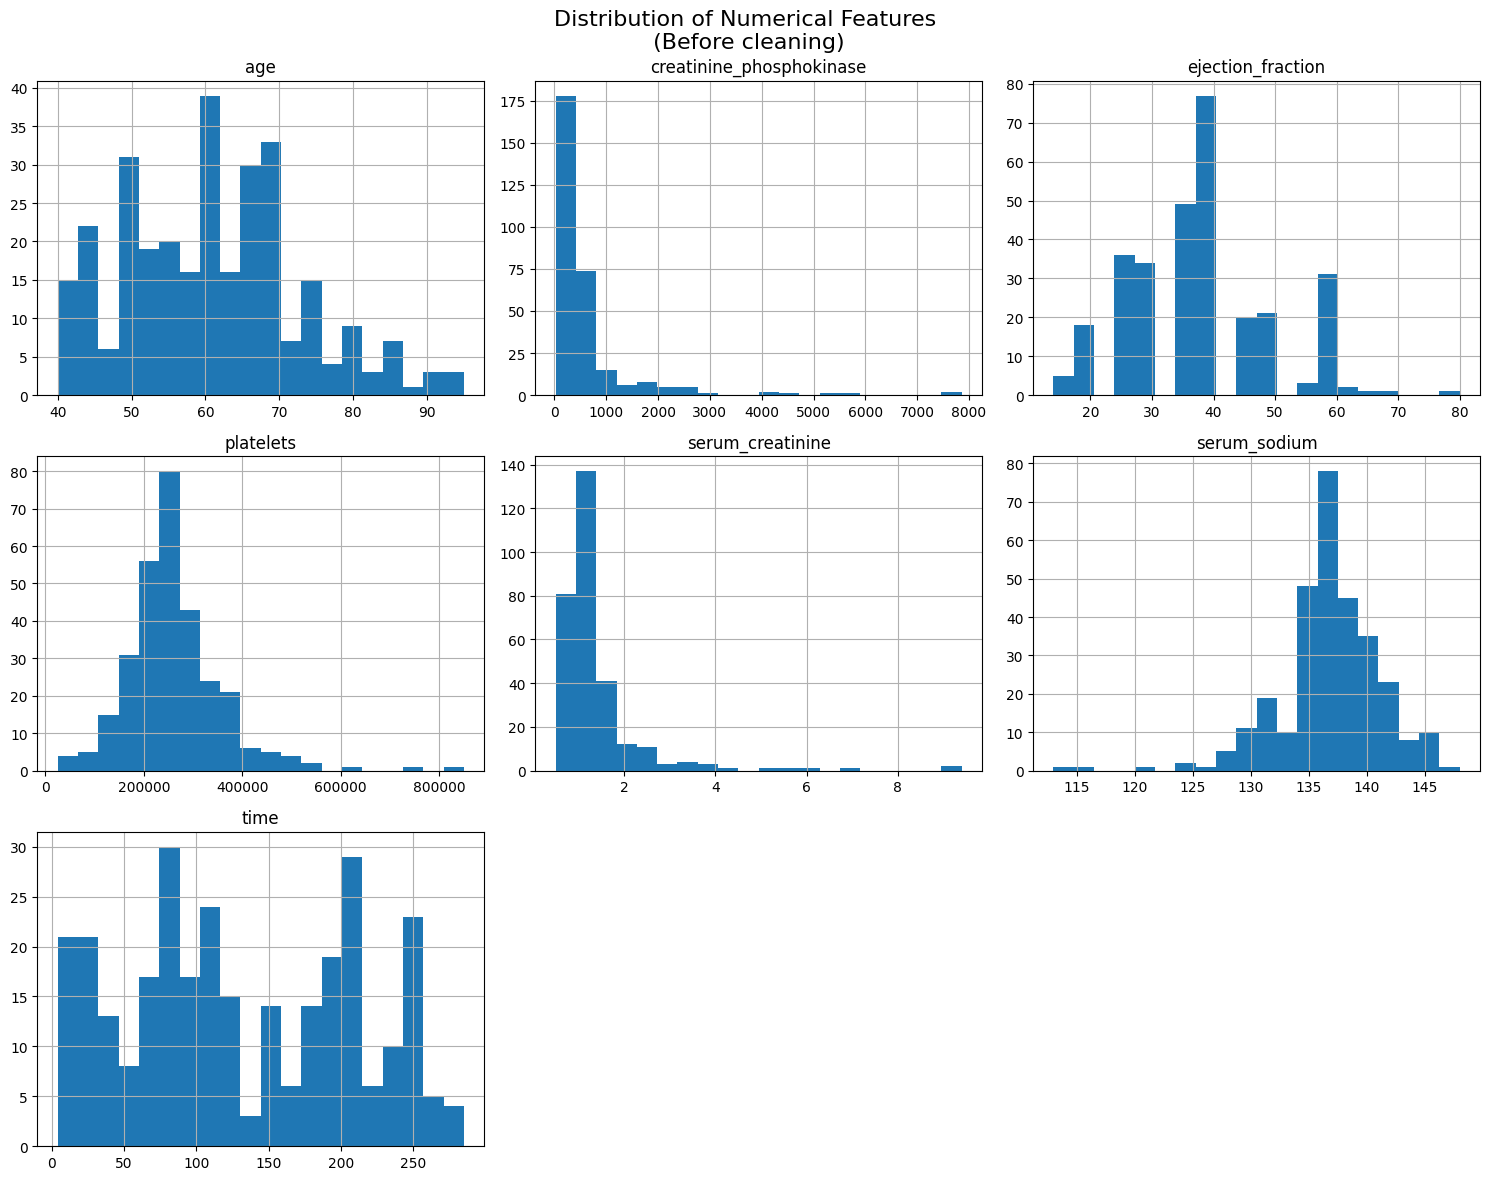

In [43]:
df[numerical_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle("Distribution of Numerical Features\n (Before cleaning)", fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
df2 = df.copy()

In [25]:
for column in numerical_columns:
    df2[column] = df2[column].fillna(df2[column].median())

print("Numerical missing values after imputation:")
print(df2[numerical_columns].isnull().sum())

Numerical missing values after imputation:
age                         0
creatinine_phosphokinase    0
ejection_fraction           0
platelets                   0
serum_creatinine            0
serum_sodium                0
time                        0
dtype: int64


In [26]:
for column in categorical_columns:
    df2[column] = df2[column].fillna(df2[column].mode()[0])

print("Categorical missing values after imputation:")
print(df2[categorical_columns].isnull().sum())

Categorical missing values after imputation:
anaemia                0
diabetes               0
high_blood_pressure    0
sex                    0
smoking                0
dtype: int64


In [27]:
# outliers
df_no_outliers = df2.copy()

for column in numerical_columns:

    Q1 = df_no_outliers[column].quantile(0.25)
    Q3 = df_no_outliers[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[column] >= lower_bound) &
        (df_no_outliers[column] <= upper_bound)
    ]

print("Rows before outlier removal:", len(df2))
print("Rows after outlier removal:", len(df_no_outliers))
print("Rows removed:", len(df2) - len(df_no_outliers))

Rows before outlier removal: 299
Rows after outlier removal: 224
Rows removed: 75


In [28]:
print("Negative age:",
      (df_no_outliers['age'] < 0).sum())

print("Negative ejection fraction:",
      (df_no_outliers['ejection_fraction'] < 0).sum())

print("Negative platelets:",
      (df_no_outliers['platelets'] < 0).sum())

print("Negative serum creatinine:",
      (df_no_outliers['serum_creatinine'] < 0).sum())

print("Negative serum sodium:",
      (df_no_outliers['serum_sodium'] < 0).sum())

Negative age: 0
Negative ejection fraction: 0
Negative platelets: 0
Negative serum creatinine: 0
Negative serum sodium: 0


In [29]:
for column in categorical_columns:
    print(column, ":", df_no_outliers[column].unique())

anaemia : [0 1]
diabetes : [0 1]
high_blood_pressure : [1 0]
sex : [1 0]
smoking : [0 1]


In [30]:
# age_group feature
def age_group(age):
    if age < 40:
        return "<40"
    elif age <= 60:
        return "40-60"
    else:
        return ">60"

df_no_outliers['age_group'] = df_no_outliers['age'].apply(age_group)

display(df_no_outliers[['age', 'age_group']].head(10))

,age,age_group
0,75.0,>60
2,65.0,>60
3,50.0,40-60
5,90.0,>60
6,75.0,>60
8,65.0,>60
11,62.0,>60
12,45.0,40-60
13,50.0,40-60
14,49.0,40-60


In [32]:
from sklearn.preprocessing import MinMaxScaler

df_no_outliers['risk_score_raw'] = (
    df_no_outliers['ejection_fraction'] *
    df_no_outliers['serum_creatinine']
)

scaler = MinMaxScaler()

df_no_outliers['risk_score'] = scaler.fit_transform(
    df_no_outliers[['risk_score_raw']]
)

df_no_outliers.drop(
    'risk_score_raw',
    axis=1,
    inplace=True
)

display(
    df_no_outliers[
        ['ejection_fraction', 'serum_creatinine', 'risk_score']
    ].head()
)

,ejection_fraction,serum_creatinine,risk_score
0,20,1.9,0.310545
2,20,1.3,0.171495
3,20,1.9,0.310545
5,40,2.1,0.843569
6,15,1.2,0.078795


In [34]:
# encoding
df_encoded = pd.get_dummies(
    df_no_outliers,
    columns=['age_group'],
    dtype=int
)

df_encoded.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_40-60,age_group_>60
0,75.0,0,582,0,20,1,265000.0,1.9,130,1,0,4,1,0.310545,0,1
2,65.0,0,146,0,20,0,162000.0,1.3,129,1,1,7,1,0.171495,0,1
3,50.0,1,111,0,20,0,210000.0,1.9,137,1,0,7,1,0.310545,1,0
5,90.0,1,47,0,40,1,204000.0,2.1,132,1,1,8,1,0.843569,0,1
6,75.0,1,246,0,15,0,127000.0,1.2,137,1,0,10,1,0.078795,0,1


In [36]:
# normalization
minmax_scaler = MinMaxScaler()

df_encoded[numerical_columns] = minmax_scaler.fit_transform(
    df_encoded[numerical_columns]
)

df_encoded[numerical_columns].head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
0,0.636364,0.470990,0.117647,0.468852,0.866667,0.217391,0.000000
2,0.454545,0.098976,0.117647,0.131148,0.466667,0.173913,0.010676
3,0.181818,0.069113,0.117647,0.288525,0.866667,0.521739,0.010676
5,0.909091,0.014505,0.509804,0.268852,1.000000,0.304348,0.014235
6,0.636364,0.184300,0.019608,0.016393,0.400000,0.521739,0.021352


In [37]:
print("Minimum values:")
print(df_encoded[numerical_columns].min())

print("\nMaximum values:")
print(df_encoded[numerical_columns].max())

Minimum values:
age                         0.0
creatinine_phosphokinase    0.0
ejection_fraction           0.0
platelets                   0.0
serum_creatinine            0.0
serum_sodium                0.0
time                        0.0
dtype: float64

Maximum values:
age                         1.0
creatinine_phosphokinase    1.0
ejection_fraction           1.0
platelets                   1.0
serum_creatinine            1.0
serum_sodium                1.0
time                        1.0
dtype: float64


In [38]:
before_cleaning = df[numerical_columns].agg(
    ['mean', 'median', 'std']
).T

print("Summary Statistics Before Cleaning:")
display(before_cleaning)

Summary Statistics Before Cleaning:


,mean,median,std
age,60.833893,60.0,11.894809
creatinine_phosphokinase,581.839465,250.0,970.287881
ejection_fraction,38.083612,38.0,11.834841
platelets,263358.029264,262000.0,97804.236869
serum_creatinine,1.393880,1.1,1.034510
serum_sodium,136.625418,137.0,4.412477
time,130.260870,115.0,77.614208


In [42]:
after_cleaning = df_no_outliers[numerical_columns].agg(
    ['mean', 'median', 'std']
).T

print("Summary Statistics After Cleaning:")
display(after_cleaning)

Summary Statistics After Cleaning:


,mean,median,std
age,60.809527,60.0,11.946085
creatinine_phosphokinase,336.941964,212.0,279.521085
ejection_fraction,38.178571,38.0,11.710801
platelets,255865.190045,262500.0,67153.749051
serum_creatinine,1.128571,1.1,0.327794
serum_sodium,137.044643,137.0,3.806740
time,132.651786,120.0,76.579770


In [40]:
comparison = pd.DataFrame({
    'Before Mean': before_cleaning['mean'],
    'After Mean': after_cleaning['mean'],
    'Before Median': before_cleaning['median'],
    'After Median': after_cleaning['median'],
    'Before Std': before_cleaning['std'],
    'After Std': after_cleaning['std']
})

display(comparison)

,Before Mean,After Mean,Before Median,After Median,Before Std,After Std
age,60.833893,60.809527,60.0,60.0,11.894809,11.946085
creatinine_phosphokinase,581.839465,336.941964,250.0,212.0,970.287881,279.521085
ejection_fraction,38.083612,38.178571,38.0,38.0,11.834841,11.710801
platelets,263358.029264,255865.190045,262000.0,262500.0,97804.236869,67153.749051
serum_creatinine,1.393880,1.128571,1.1,1.1,1.034510,0.327794
serum_sodium,136.625418,137.044643,137.0,137.0,4.412477,3.806740
time,130.260870,132.651786,115.0,120.0,77.614208,76.579770


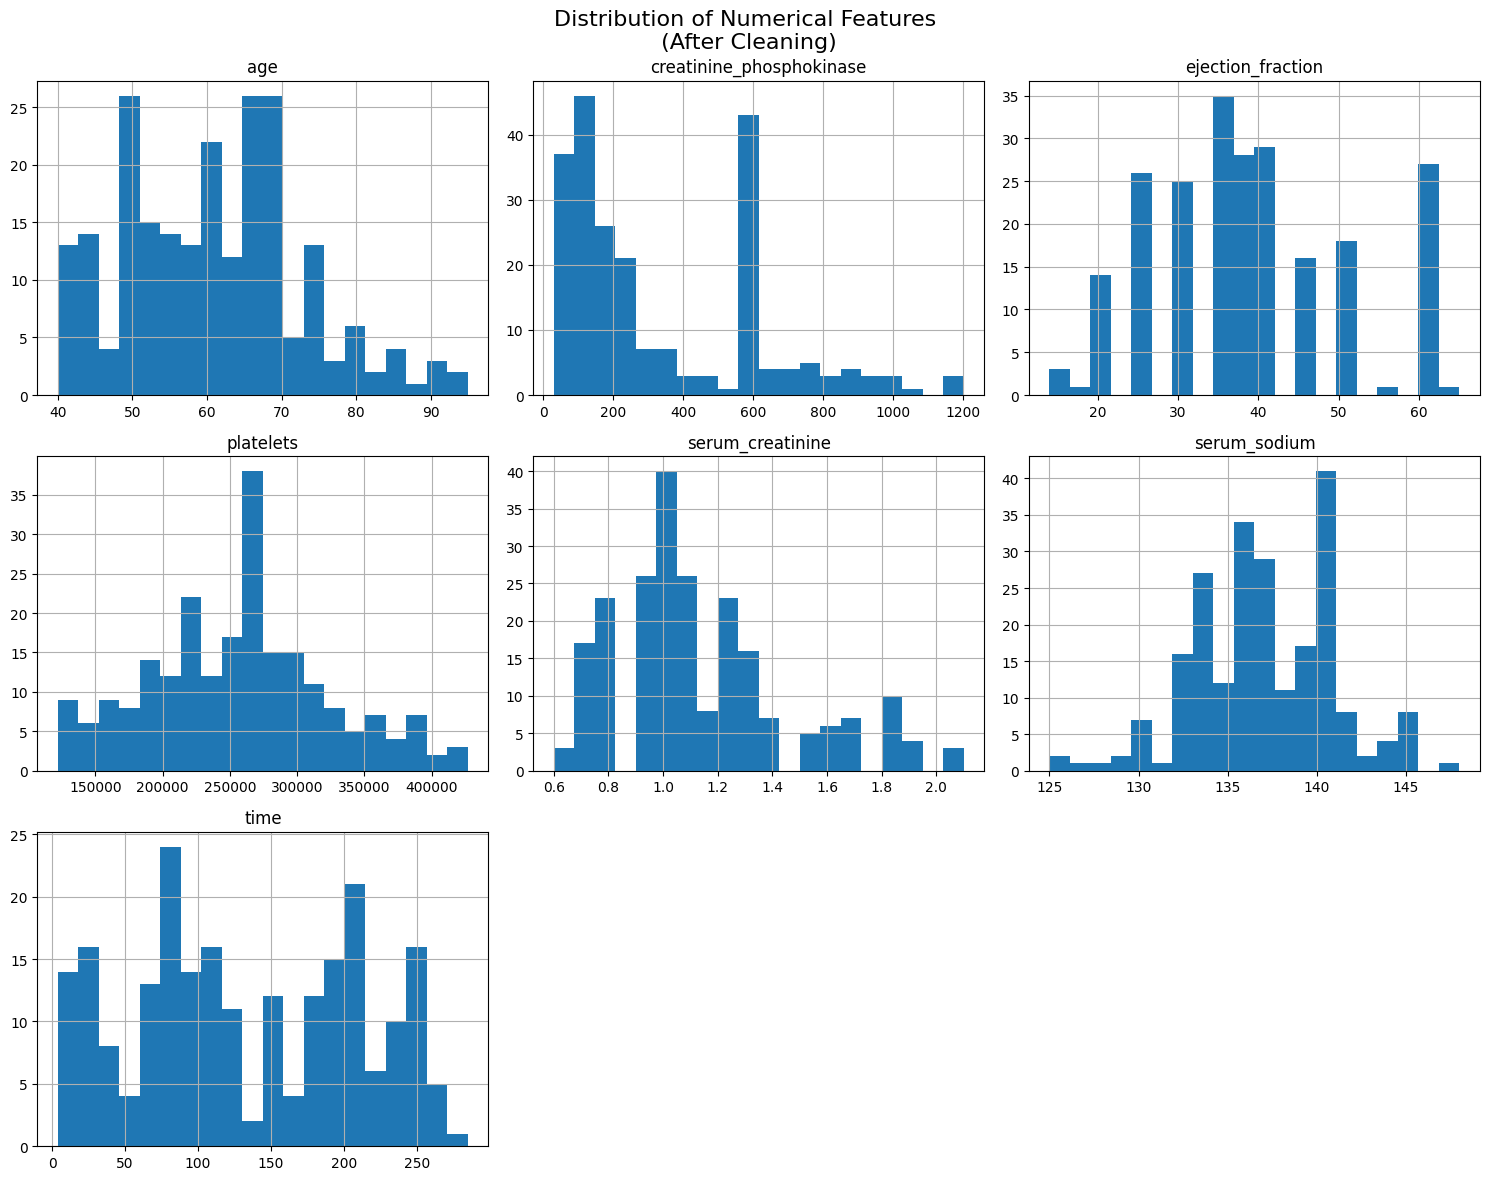

In [44]:
df_no_outliers[numerical_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features\n (After Cleaning)",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [46]:
print(df_encoded.isnull().sum())

print("\nTotal missing values:", df_encoded.isnull().sum().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_40-60             0
age_group_>60               0
dtype: int64

Total missing values: 0
